In [42]:
import pandas as pd
import os
import numpy as np
from datetime import datetime

In [43]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_cytokine_stochastic_metrics"

In [44]:
directory = file_dir

In [45]:

today_midnight = 1771455600.0

files_today = []

for filename in os.listdir(directory):
    path = os.path.join(directory, filename)

    if not os.path.isfile(path):
        continue

    if os.path.getmtime(path) >= today_midnight:
        files_today.append(filename)

len(files_today)

37

In [46]:
dfs = []
for f in files_today:
    df = pd.read_csv(os.path.join(file_dir, f), index_col=0)
    df["reg"] = f.split("_")[-1].strip(".csv")
    dfs.append(df) 

df = pd.concat(dfs, axis=0)

In [47]:
df_stoch = df[df["reg"]=="0.1"]

In [48]:
df_stoch["donor_cytokine"] = df_stoch.index
df_stoch["donor"] = df_stoch.apply(lambda x: x["donor_cytokine"].split("_")[0], axis=1)
df_stoch["cytokine"] = df_stoch.apply(lambda x: x["donor_cytokine"].split("_")[1], axis=1)

/tmp/ipykernel_153524/4282705999.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stoch["donor_cytokine"] = df_stoch.index
/tmp/ipykernel_153524/4282705999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stoch["donor"] = df_stoch.apply(lambda x: x["donor_cytokine"].split("_")[0], axis=1)
/tmp/ipykernel_153524/4282705999.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [8]:
unique_conditions = list(df_stoch.index.unique())

In [10]:
df_other = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine.csv", index_col=0)
df_other = df_other[df_other['num_donors_in_train']==1]
#df_other = df_other.set_index("donor_cytokine")

/tmp/ipykernel_153524/3498182454.py:1: DtypeWarning: Columns (1,128,129,171) have mixed types. Specify dtype option on import or set low_memory=False.
  df_other = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine.csv", index_col=0)


In [10]:
df_other.index = df_other.index.str.replace(r'_1$', '', regex=True)

In [11]:
#df_other = df_other["Unnamed: 0"]
#df_other.index = df_other["Unnamed: 0"]
df_other["mean_ood_e_distance"] = df_other["ood_e_distance"]
df_other["mean_deg_r"] = df_other['mean_deg_r_sq_per_cell_type']

In [12]:
df_cf = df_other[df_other["method"]=="cf"]
df_cf = df_cf.set_index("Unnamed: 0")
df_cl = df_other[df_other["method"]=="cl"]
df_cl = df_cl.set_index("Unnamed: 0")
df_cl.index = df_cl.index.str.replace(r'_1$', '', regex=True)

In [13]:
df_stoch["method"] = "cf_stoch"
df = pd.concat((df_stoch, df_other[~df_other["method"].isin(("cf", "cl"))], df_cf, df_cl))

/tmp/ipykernel_798422/3981581279.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stoch["method"] = "cf_stoch"


In [14]:
df["method"].value_counts()

method
cf_stoch    396
m1          396
m2          396
cf          396
cl          396
id          144
Name: count, dtype: int64

In [15]:
df.to_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine_with_stochastic_1_seen.csv")

<Axes: xlabel='method', ylabel='mean_ood_e_distance'>

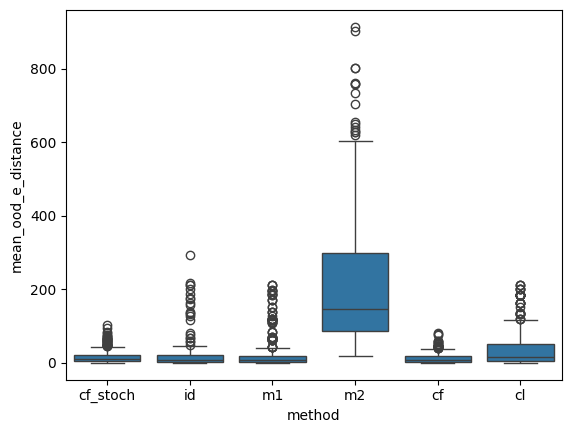

In [16]:
import seaborn as sns
sns.boxplot(df, y="mean_ood_e_distance", x="method")

<Axes: xlabel='method', ylabel='mean_deg_r_sq_per_cell_type'>

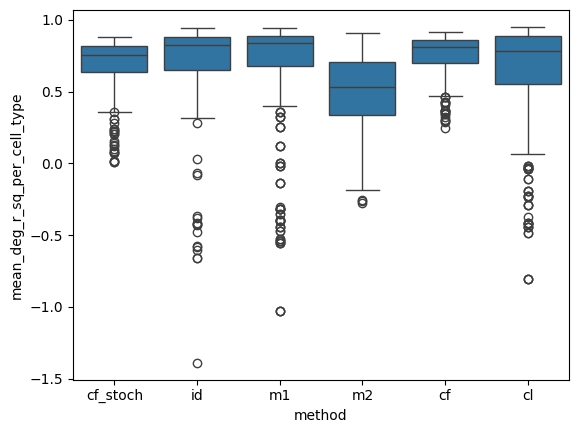

In [17]:
sns.boxplot(df, y="mean_deg_r_sq_per_cell_type", x="method")

In [110]:
df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics/paired_metrics_new_cytokine.csv")

In [112]:
df = df[df["num_donors_in_train"]==1]


In [ ]:
from scipy.stats import ttest_rel

In [113]:
ttest_rel(df["ood_e_distance_cf_stoch"].values, df["ood_e_distance_cf"].values)

TtestResult(statistic=4.543892665640171, pvalue=7.469898315356743e-06, df=373)

In [114]:
ttest_rel(df["ood_e_distance_cf_stoch"].values, df["ood_e_distance_m1"].values)

TtestResult(statistic=-5.0481869057744735, pvalue=6.987737159937908e-07, df=373)

In [115]:
ttest_rel(df["ood_e_distance_cf_stoch"].values, df["ood_e_distance_m2"].values)

TtestResult(statistic=-21.412849952815982, pvalue=6.494049161400785e-67, df=373)

In [116]:
ttest_rel(df["ood_e_distance_cf_stoch"].values, df["ood_e_distance_id"].values)

TtestResult(statistic=-5.583913034095409, pvalue=4.536516756189069e-08, df=373)

In [117]:
ttest_rel(df["ood_e_distance_cf_stoch"].values, df["ood_e_distance_cl"].values)

TtestResult(statistic=-10.314195841255193, pvalue=4.1226680810762476e-22, df=373)

In [118]:
ttest_rel(df["mean_deg_r_sq_per_cell_type_cf_stoch"].values, df["mean_deg_r_sq_per_cell_type_cf"].values)

TtestResult(statistic=-17.47776616910713, pvalue=2.141051412251014e-50, df=373)

In [119]:
ttest_rel(df["mean_deg_r_sq_per_cell_type_cf_stoch"].values, df["mean_deg_r_sq_per_cell_type_m1"].values)

TtestResult(statistic=0.8380730263981835, pvalue=0.4025263946500731, df=373)

In [120]:
ttest_rel(df["mean_deg_r_sq_per_cell_type_cf_stoch"].values, df["mean_deg_r_sq_per_cell_type_m2"].values)

TtestResult(statistic=14.475121651169248, pvalue=5.34252782011475e-38, df=373)

In [121]:
ttest_rel(df["mean_deg_r_sq_per_cell_type_cf_stoch"].values, df["mean_deg_r_sq_per_cell_type_id"].values)

TtestResult(statistic=2.095648194955583, pvalue=0.03678701249183124, df=373)

In [122]:
ttest_rel(df["mean_deg_r_sq_per_cell_type_cf_stoch"].values, df["mean_deg_r_sq_per_cell_type_cl"].values)

TtestResult(statistic=4.1019930779974585, pvalue=5.032315902934519e-05, df=373)